In [1]:
# # Oasis Infobyte Internship

# # Level 2 - Task 4

# # Google Play Store Analysis

# **Name:** Jigyasha Jain

# ## Objective

# Perform exploratory data analysis and sentiment analysis on the Google Play Store dataset to understand app trends, pricing, ratings, installs, and user opinions.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

import plotly.express as px

%matplotlib inline

In [5]:
apps = pd.read_csv("googleplaystore.csv.zip")

reviews = pd.read_csv("googleplaystore_user_reviews.csv.zip")

In [6]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [8]:
apps.shape

(10841, 13)

In [9]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [10]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [11]:
# ## Initial Inspection

# The project uses two datasets:

# - Google Play Store Apps dataset
# - Google Play Store User Reviews dataset

# The datasets contain application information, ratings, installs, pricing, and user review sentiment.

In [12]:
apps.drop_duplicates(inplace=True)

reviews.drop_duplicates(inplace=True)

In [13]:
apps.isnull().sum()

App                  0
Category             0
Rating            1465
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [14]:
reviews.isnull().sum()

App                         0
Translated_Review         987
Sentiment                 982
Sentiment_Polarity        982
Sentiment_Subjectivity    982
dtype: int64

In [15]:
apps["Installs"] = apps["Installs"].str.replace(",", "")
apps["Installs"] = apps["Installs"].str.replace("+", "", regex=False)

apps["Installs"] = pd.to_numeric(
    apps["Installs"],
    errors="coerce"
)

In [16]:
apps["Price"] = apps["Price"].str.replace("$", "", regex=False)

apps["Price"] = pd.to_numeric(
    apps["Price"],
    errors="coerce"
)

In [17]:
apps["Reviews"] = pd.to_numeric(
    apps["Reviews"],
    errors="coerce"
)

In [18]:
apps["Size"] = apps["Size"].replace("Varies with device", np.nan)

apps["Size"] = apps["Size"].str.replace("M", "", regex=False)

apps["Size"] = apps["Size"].str.replace("k", "", regex=False)

apps["Size"] = pd.to_numeric(
    apps["Size"],
    errors="coerce"
)

In [19]:
apps.fillna({
    "Rating": apps["Rating"].median(),
    "Size": apps["Size"].median(),
    "Price": 0
}, inplace=True)

reviews.dropna(inplace=True)

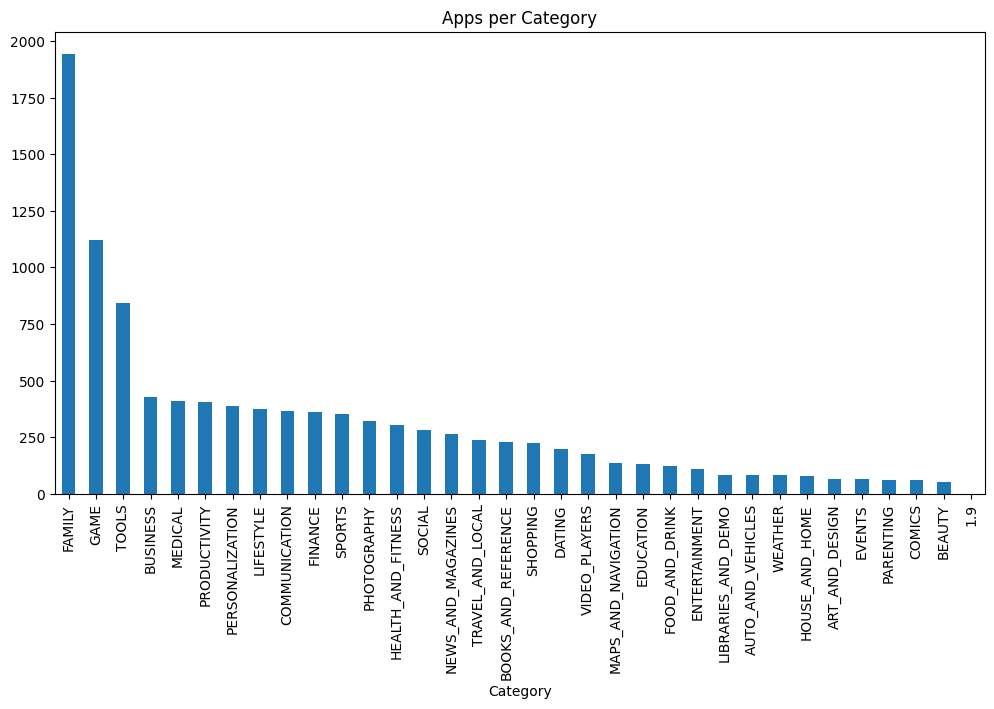

In [20]:
plt.figure(figsize=(12,6))

apps["Category"].value_counts().plot(kind="bar")

plt.title("Apps per Category")

plt.show()

In [22]:
# ## Observation

# The categories with the highest number of applications are the most saturated markets on the Google Play Store.

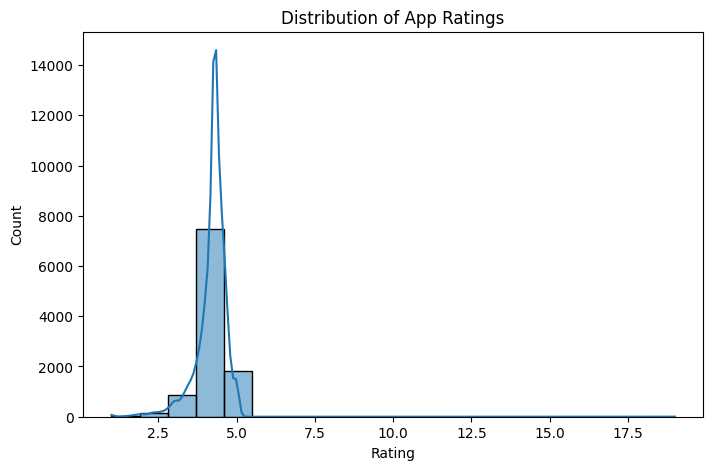

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    apps["Rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")

plt.show()

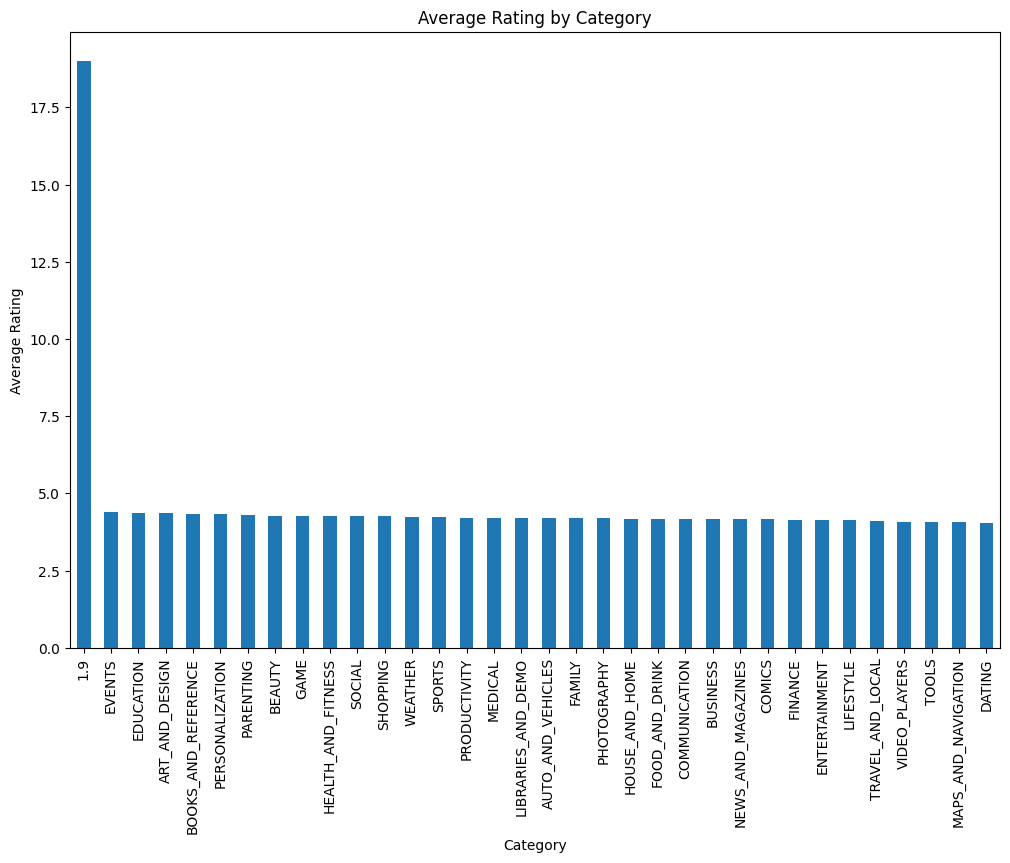

In [24]:
avg_rating = apps.groupby("Category")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))

avg_rating.plot(kind="bar")

plt.title("Average Rating by Category")
plt.ylabel("Average Rating")

plt.show()

In [25]:
# ## Observation

# Most applications have ratings between 4.0 and 4.5. Categories with higher average ratings indicate better user satisfaction.

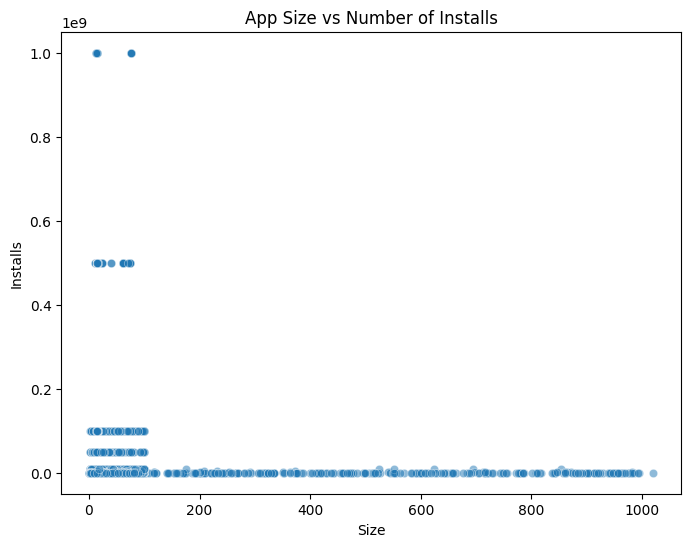

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=apps,
    x="Size",
    y="Installs",
    alpha=0.5
)

plt.title("App Size vs Number of Installs")

plt.show()

In [27]:
# ## Observation

# There is no strong relationship between app size and the number of installs. Small as well as large apps can achieve high download counts.

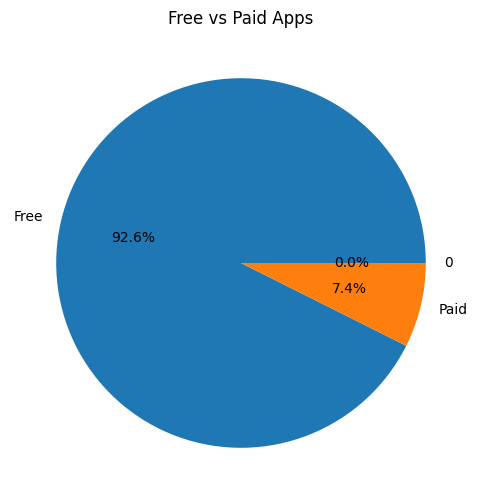

In [28]:
plt.figure(figsize=(6,6))

apps["Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Free vs Paid Apps")

plt.ylabel("")

plt.show()

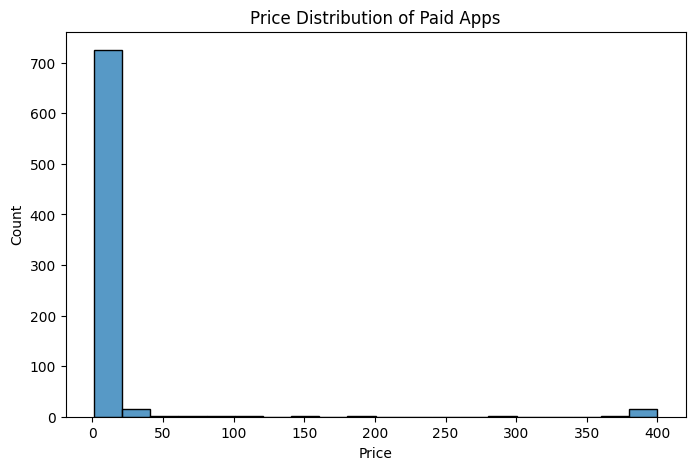

In [29]:
paid_apps = apps[apps["Type"]=="Paid"]

plt.figure(figsize=(8,5))

sns.histplot(
    paid_apps["Price"],
    bins=20
)

plt.title("Price Distribution of Paid Apps")

plt.show()

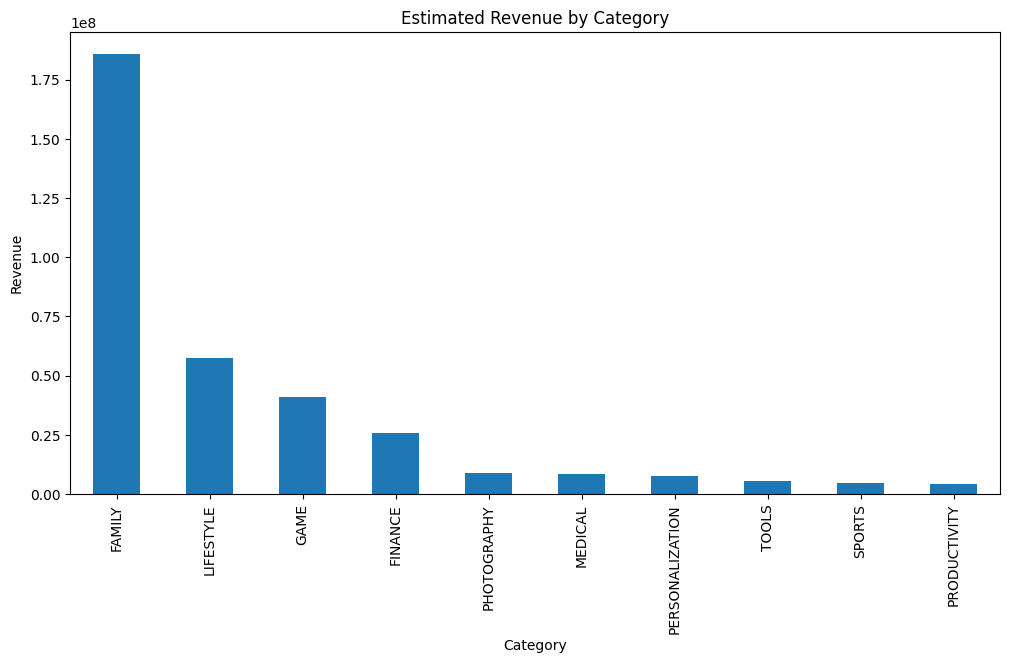

In [30]:
apps["Estimated Revenue"] = apps["Price"] * apps["Installs"]

revenue = apps.groupby("Category")["Estimated Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

revenue.head(10).plot(kind="bar")

plt.title("Estimated Revenue by Category")

plt.ylabel("Revenue")

plt.show()

In [31]:
# ## Observation

# Most applications on the Play Store are free. Paid applications are relatively few but some categories generate higher estimated revenue due to premium pricing.

In [32]:
from textblob import TextBlob

In [33]:
def get_sentiment(review):

    polarity = TextBlob(str(review)).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

In [34]:
reviews["Sentiment"] = reviews["Translated_Review"].apply(get_sentiment)

reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000


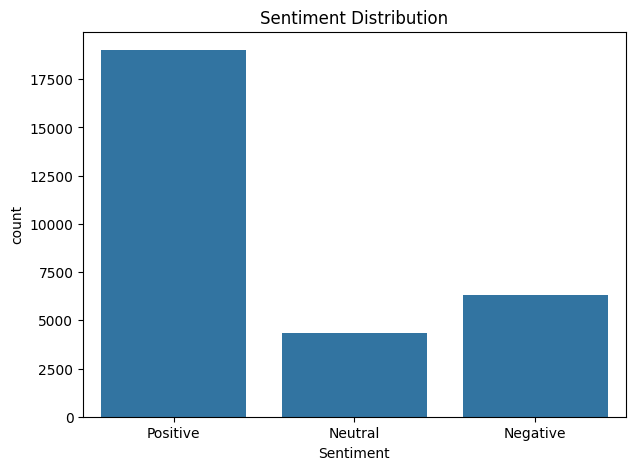

In [35]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=reviews,
    x="Sentiment"
)

plt.title("Sentiment Distribution")

plt.show()

In [36]:
# ## Observation

# Positive reviews are generally more frequent than negative reviews, indicating that many users are satisfied with their applications.

In [37]:
merged = pd.merge(
    reviews,
    apps,
    on="App",
    how="inner"
)

merged.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Estimated Revenue
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,HEALTH_AND_FITNESS,4.0,2490.0,3.8,500000.0,Free,0.0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,0.0
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,HEALTH_AND_FITNESS,4.0,2490.0,3.8,500000.0,Free,0.0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,0.0
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,HEALTH_AND_FITNESS,4.0,2490.0,3.8,500000.0,Free,0.0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,0.0
3,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,HEALTH_AND_FITNESS,4.0,2490.0,3.8,500000.0,Free,0.0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,0.0
4,10 Best Foods for You,Best way,Positive,1.00,0.300000,HEALTH_AND_FITNESS,4.0,2490.0,3.8,500000.0,Free,0.0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,0.0


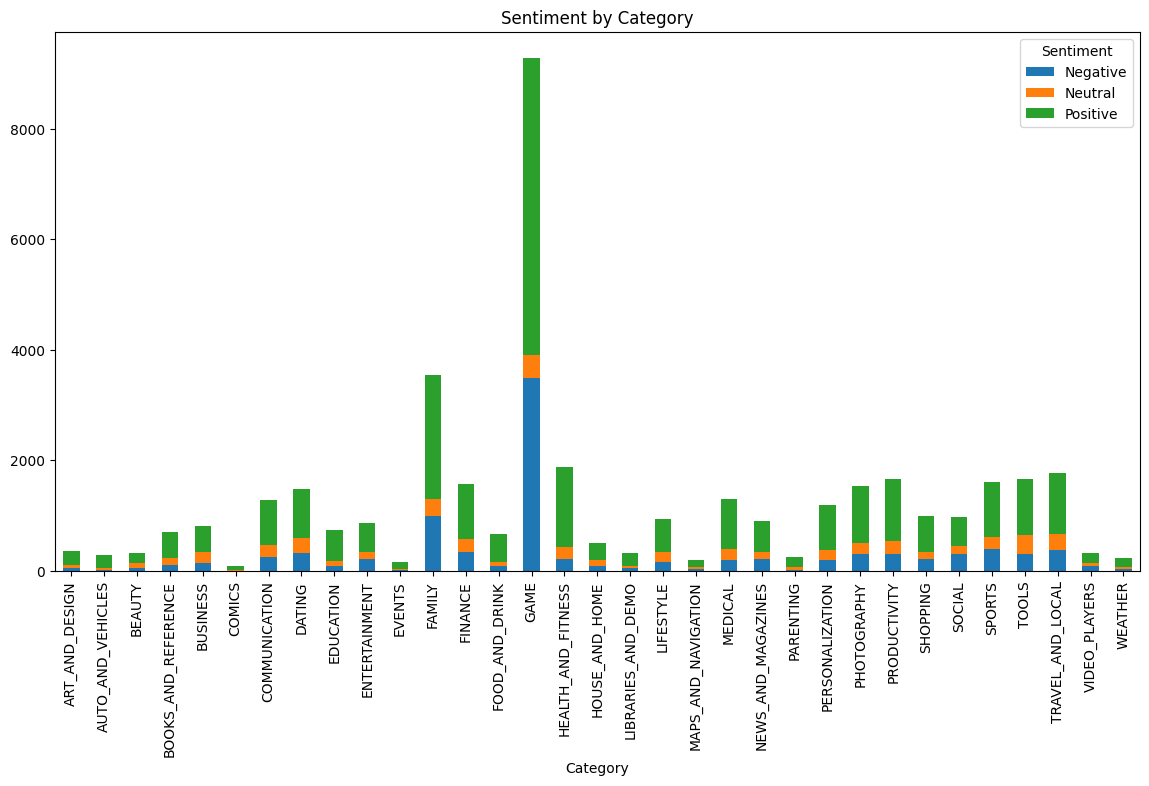

In [38]:
sentiment_category = pd.crosstab(
    merged["Category"],
    merged["Sentiment"]
)

sentiment_category.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.title("Sentiment by Category")

plt.show()

In [40]:
# ## Observation

# Some categories receive significantly more positive reviews, while others attract relatively more negative feedback, highlighting differences in user satisfaction across app categories.

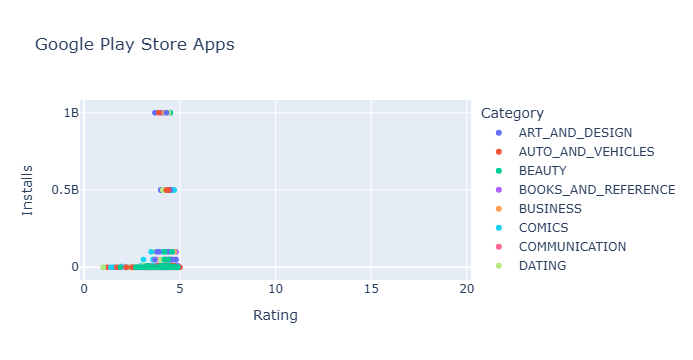

In [41]:
import plotly.express as px

fig = px.scatter(
    apps,
    x="Rating",
    y="Installs",
    color="Category",
    hover_name="App",
    title="Google Play Store Apps"
)

fig.show()

In [42]:
# # Conclusion

# ## Insight 1

# Most applications on Google Play are free, making the marketplace highly competitive. Revenue is mainly generated through premium apps and in-app purchases.

# ## Insight 2

# Applications with ratings above 4.0 generally receive more installs, suggesting that user satisfaction strongly influences popularity.

# ## Insight 3

# Categories such as Family, Game, and Tools dominate the Play Store in terms of app count, while business opportunities may exist in less saturated categories with high user ratings.

# ## Recommendation

# A developer launching a new application should focus on maintaining high quality, achieving positive user reviews, and selecting categories with strong demand but moderate competition.